## **Install Dependencies**

In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Import Library**

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from scipy.stats import ttest_rel, permutation_test, wilcoxon

from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score, confusion_matrix)

from mealpy.swarm_based import GWO
from cauchy_gaussian_gwo import CG_GWO
from mealpy.utils.space import FloatVar
from joint_optimization import SVMJointOptimization

import warnings
np.random.seed(42)
warnings.filterwarnings("ignore")

## **Import Dataset**

In [3]:
# nama kolom dataset breast cancer wisconsin
columns = [
    "id", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [4]:
# import data
df = None

try:
    dataset = fetch_ucirepo(id=17)
    X = dataset.data.features
    y = dataset.data.targets
    df = pd.concat([X, y], axis=1)
    print("Data loaded from UCI repository")

except Exception as e1:
    print("UCI load failed:", e1)
    try:
        filepath = './data/wdbc.data'
        df = pd.read_csv(filepath, header=None)
        df.columns = columns
        print("Data loaded from local file")
    
    except Exception as e2:
        print("Local file load failed:", e2)
        data = load_breast_cancer()
        X = pd.DataFrame(data.data, columns=data.feature_names)
        y = pd.Series(1 - data.target, name='diagnosis')
        df = pd.concat([X, y], axis=1)
        print("Data loaded from sklearn dataset")

Data loaded from UCI repository


In [5]:
dataset = fetch_ucirepo(id=17)
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)
print("Data loaded from UCI repository")

Data loaded from UCI repository


In [6]:
df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


In [7]:
# melihat 5 data pertama
df.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [8]:
# melihat informasi dasar dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

## **🔍Exploratory Data Analysis**

EDA dilakukan untuk memahami karakteristik dasar dataset sebelum pemodelan. Fokus utama meliputi:

- Analisis distribusi fitur dan target
- Identifikasi *missing values* dan outlier
- Pemeriksaan hubungan awal antar variabel

Tahap ini membantu dalam mendeteksi potensi masalah pada data serta memberikan insight awal yang dapat memengaruhi strategi preprocessing dan pemodelan.


In [9]:
# jumlah nilai unik di setiap kolom
df.nunique()

radius1               456
texture1              479
perimeter1            522
area1                 539
smoothness1           474
compactness1          537
concavity1            537
concave_points1       542
symmetry1             432
fractal_dimension1    499
radius2               540
texture2              519
perimeter2            533
area2                 528
smoothness2           547
compactness2          541
concavity2            533
concave_points2       507
symmetry2             498
fractal_dimension2    545
radius3               457
texture3              511
perimeter3            514
area3                 544
smoothness3           411
compactness3          529
concavity3            539
concave_points3       492
symmetry3             500
fractal_dimension3    535
Diagnosis               2
dtype: int64

In [10]:
# jumlah nilai yang hilang di setiap kolom
df.isna().sum()

radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
Diagnosis             0
dtype: int64

In [11]:
# jumlah data duplikat
df.duplicated().sum()

0

In [12]:
# melihat nilai statistika deskriptif kolom numerik
df.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [13]:
# mengkategorikan feature berdasarkan nama bagian
radius = [col for col in df.columns if 'radius' in col]
fractal_dimension = [col for col in df.columns if 'fractal_dimension' in col or 'fractal dimension' in col]
texture = [col for col in df.columns if 'texture' in col]
perimeter = [col for col in df.columns if 'perimeter' in col]
area = [col for col in df.columns if 'area' in col]
smoothness = [col for col in df.columns if 'smoothness' in col]
compactness = [col for col in df.columns if 'compactness' in col]
concavity = [col for col in df.columns if 'concavity' in col]
concave_points = [col for col in df.columns if 'concave_points' in col or 'concave points' in col]
symmetry = [col for col in df.columns if 'symmetry' in col]

# **📈Data Visualization**

Data visualization digunakan untuk merepresentasikan pola dan hubungan dalam data secara visual agar lebih mudah dipahami. Beberapa pendekatan yang digunakan antara lain:

- Plot distribusi (histogram/KDE)
- Visualisasi hubungan antar fitur (scatter plot, pairplot)
- Visualisasi perbandingan berdasarkan target (boxplot, violin plot)

Visualisasi ini membantu mengungkap pola tersembunyi, memperkuat hasil EDA, serta mendukung interpretasi data secara lebih intuitif.

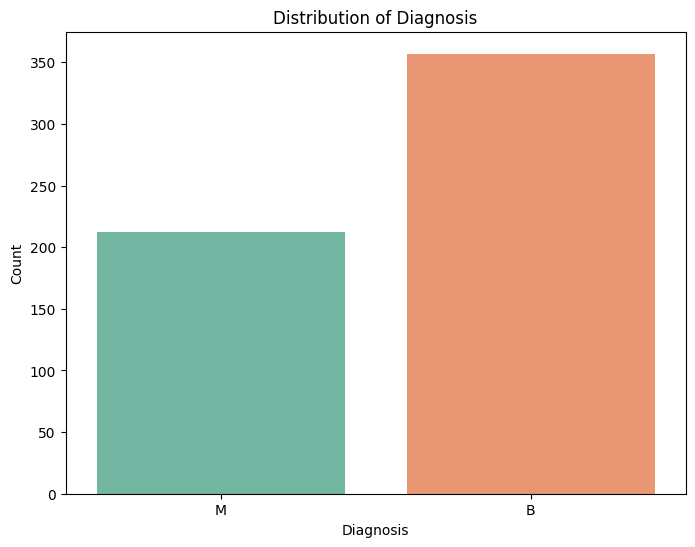

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

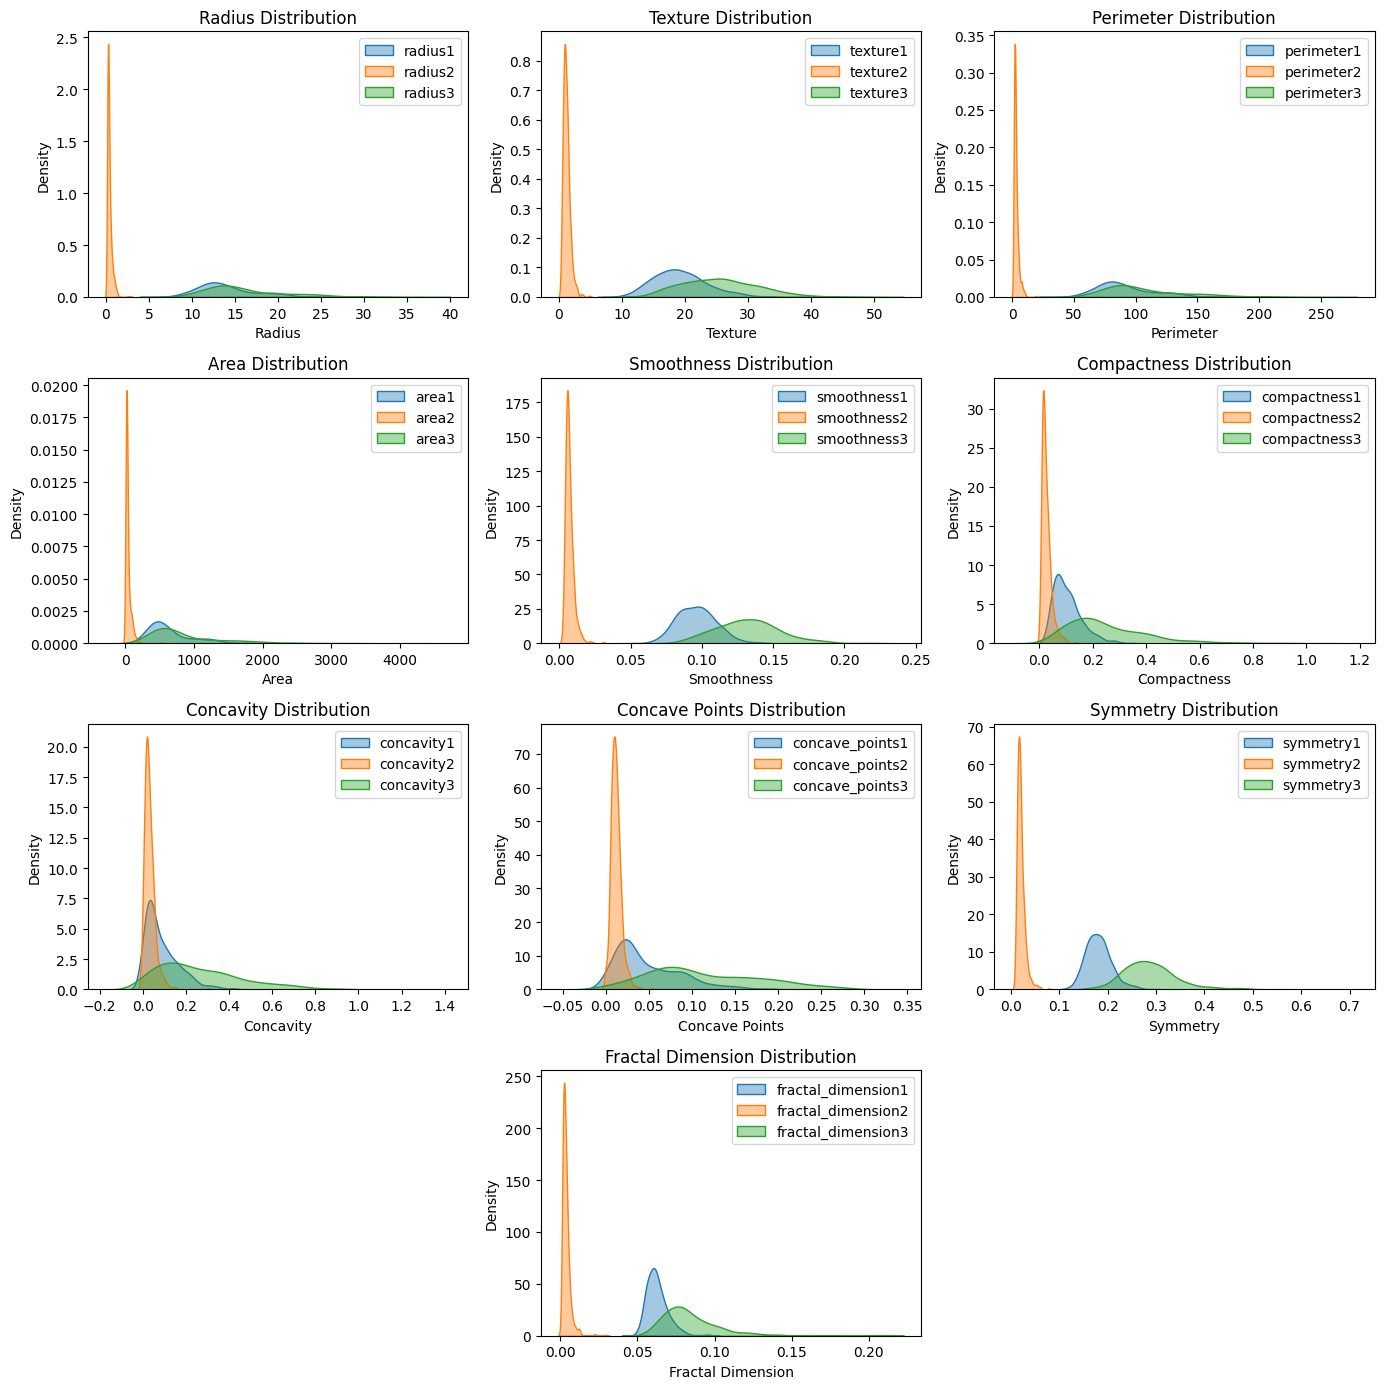

In [15]:
feature_groups = {
    "Radius": radius,
    "Texture": texture,
    "Perimeter": perimeter,
    "Area": area,
    "Smoothness": smoothness,
    "Compactness": compactness,
    "Concavity": concavity,
    "Concave Points": concave_points,
    "Symmetry": symmetry,
    "Fractal Dimension": fractal_dimension
}

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()

for i, (group_name, cols) in enumerate(feature_groups.items()):
    if i == 9:
        i+=1
        plt.delaxes(axes[9])
    ax = axes[i]
    for col in cols:
        sns.kdeplot(data=df, x=col, ax=ax, fill=True, label=col, alpha=0.4)
    
    ax.set_title(f"{group_name} Distribution")
    ax.set_xlabel(group_name)
    ax.set_ylabel("Density")
    ax.legend()

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.delaxes(axes[-1])
plt.tight_layout()
plt.show()

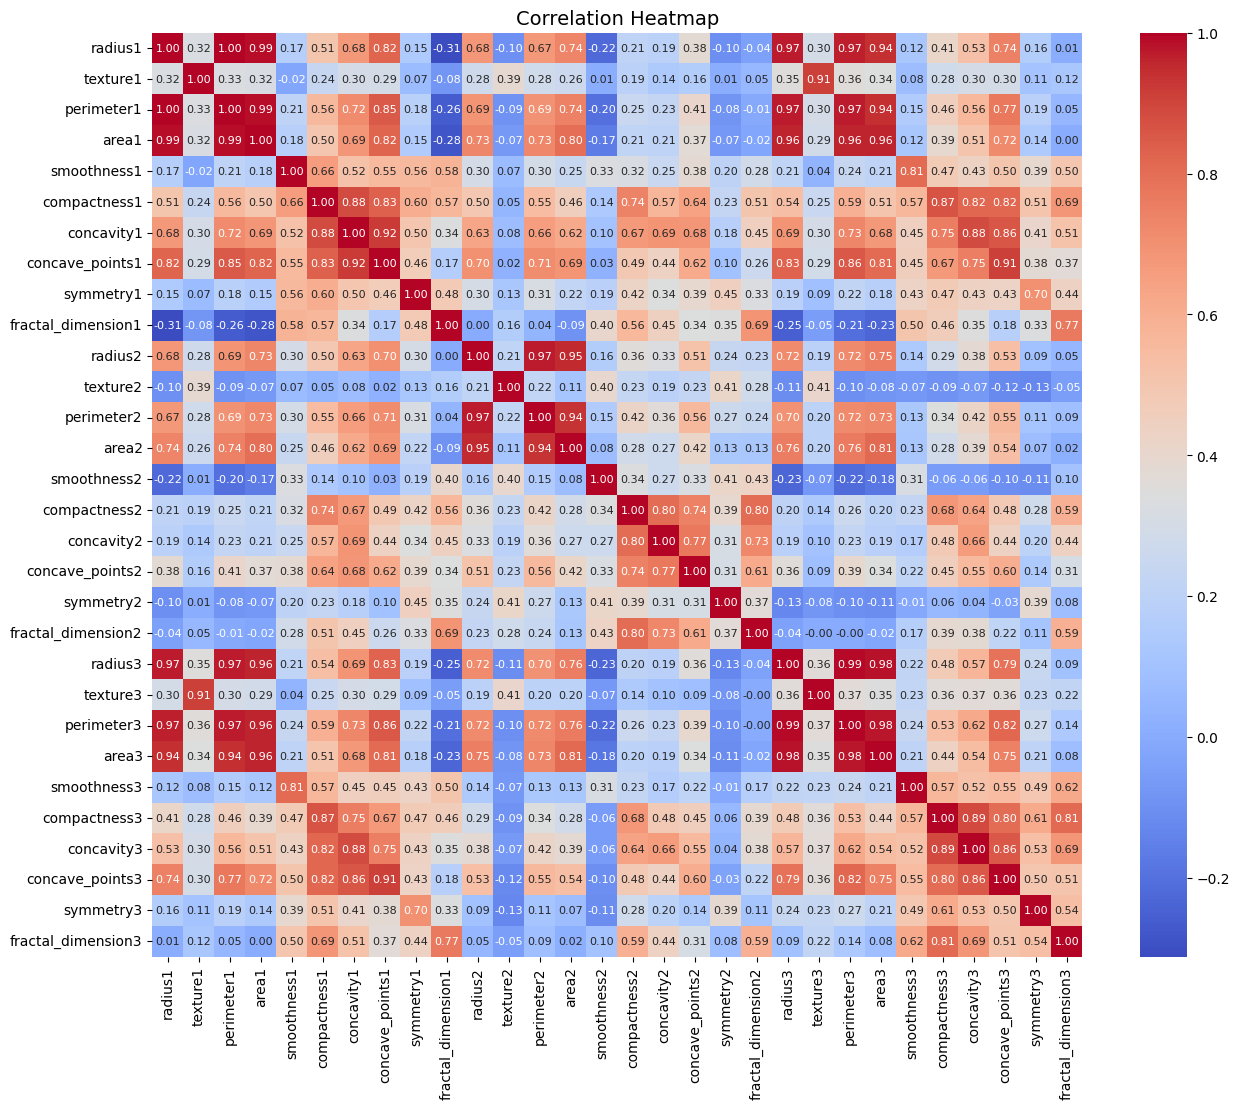

In [16]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.drop('Diagnosis', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f',annot_kws={"size": 8})
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

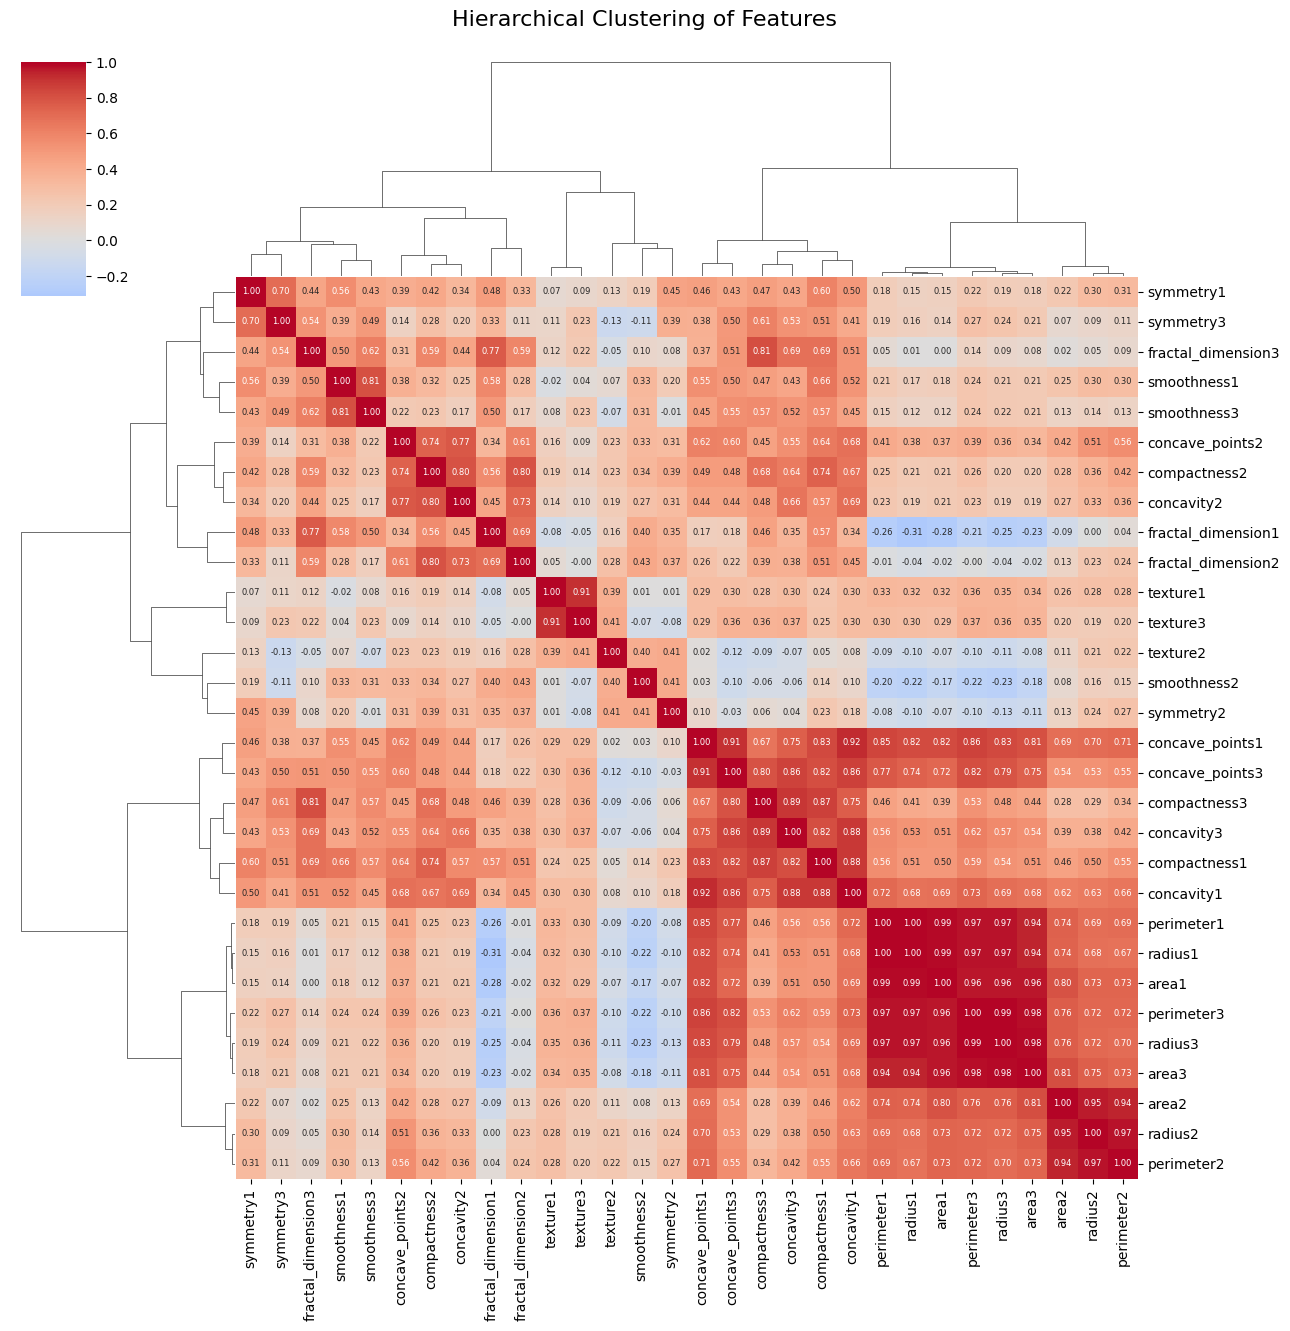

In [17]:
g = sns.clustermap(df.drop('Diagnosis', axis=1).corr(), cmap='coolwarm', center=0, figsize=(13, 13), method='ward', metric='euclidean', annot=True, fmt=".2f", annot_kws={"size": 6})
g.fig.suptitle('Hierarchical Clustering of Features', fontsize=16, y=1.02)
plt.show()

# **⚙️Data Preprocessing**

Tahap *data preprocessing* dilakukan untuk memastikan data siap digunakan oleh model SVM dan proses optimasi. Langkah-langkah utama meliputi:

- **Encoding Target**  
  Label target dikonversi ke format numerik agar dapat diproses oleh model machine learning.
- **Train-Test Split**  
  Dataset dibagi menjadi data latih dan data uji untuk mengevaluasi kemampuan generalisasi model terhadap data yang belum pernah dilihat.
- **Standard Scaling**  
  Fitur dinormalisasi menggunakan *standardization* (mean = 0, std = 1) untuk memastikan semua fitur berada pada skala yang sama, yang sangat penting bagi performa SVM.

Tahapan ini bertujuan untuk meningkatkan stabilitas, konsistensi, dan performa model selama proses pelatihan dan evaluasi.

In [18]:
# encoding label diagnosis menjadi 1 untuk M dan 0 untuk B
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

In [19]:
# memisahkan fitur dan target
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

In [20]:
# membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

Training set size: 398 samples
Testing set size: 171 samples


In [21]:
# melakukan feature scaling menggunakan StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **🧩Baseline Model**

Tahap ini digunakan **model Support Vector Machine (SVM)** sebagai *baseline* dengan cara melatihnya **langsung pada dataset tanpa optimasi** (tanpa feature selection maupun hyperparameter tuning).

Tujuan dari baseline ini adalah:
- Menyediakan **titik acuan awal** performa model
- Menjadi pembanding untuk mengevaluasi **efektivitas peningkatan** dari metode optimasi seperti GWO dan CG-GWO

Dengan demikian, setiap peningkatan performa yang diperoleh dari metode optimasi dapat diukur secara jelas terhadap model dasar yang sederhana dan tidak dioptimalkan.

In [22]:
# membangun model SVM baseline
svm_baseline = SVC(probability=True, random_state=42)
svm_baseline.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
# melakukan prediksi dengan model SVM baseline
y_pred_baseline = svm_baseline.predict(X_test_scaled)
y_prob_baseline = svm_baseline.predict_proba(X_test_scaled)[:, 1]

In [24]:
# menghitung metrik evaluasi untuk model SVM baseline
acc_baseline = accuracy_score(y_test, y_pred_baseline)
rec_baseline = recall_score(y_test, y_pred_baseline)
prec_baseline = precision_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)

print(f'Baseline SVM Accuracy   : {acc_baseline:.4f}')
print(f'Baseline SVM Recall     : {rec_baseline:.4f}')
print(f'Baseline SVM Precision  : {prec_baseline:.4f}')
print(f'Baseline SVM F1 Score   : {f1_baseline:.4f}')

Baseline SVM Accuracy   : 0.9766
Baseline SVM Recall     : 0.9683
Baseline SVM Precision  : 0.9683
Baseline SVM F1 Score   : 0.9683


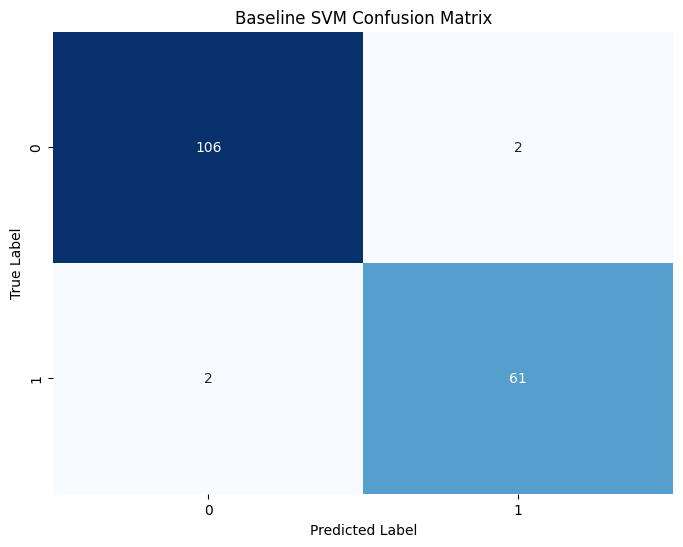

In [25]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

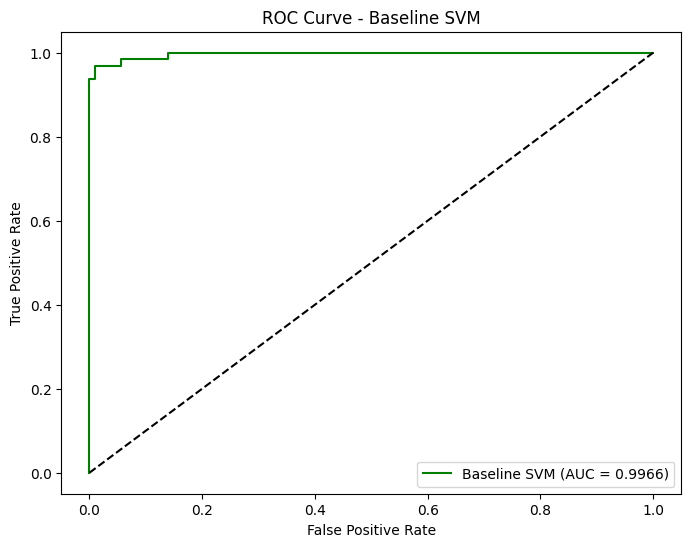

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Baseline SVM (AUC = {roc_auc_baseline:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline SVM')
plt.legend()
plt.show()

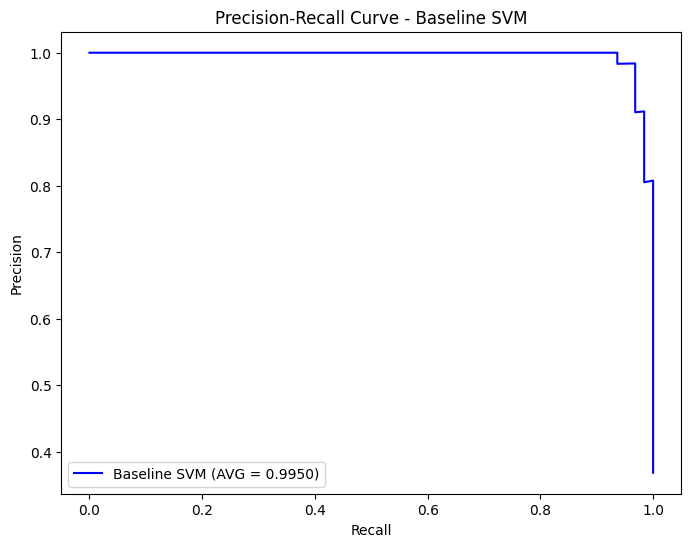

In [27]:
prec_baseline_curve, rec_baseline_curve, _ = precision_recall_curve(y_test, y_prob_baseline)
pr_auc_baseline = average_precision_score(y_test, y_prob_baseline)

plt.figure(figsize=(8, 6))
plt.plot(rec_baseline_curve, prec_baseline_curve, label=f'Baseline SVM (AVG = {pr_auc_baseline:.4f})', color='blue')
plt.title('Precision-Recall Curve - Baseline SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

## **🔁Implementation of AutoML Using the GWO and CG-GWO Algorithms**

**Grey Wolf Optimizer (GWO)** adalah algoritma *metaheuristic swarm intelligence* yang terinspirasi dari perilaku berburu serigala abu-abu. Mekanisme utamanya melibatkan:
- **Hierarki sosial**: α (alpha), β (beta), δ (delta), dan ω (omega)
- **Strategi berburu**: *encircling*, *hunting*, dan *attacking prey*

GWO memodelkan proses optimasi sebagai pergerakan populasi solusi yang dipandu oleh tiga solusi terbaik (α, β, δ), sehingga mampu mengeksplorasi dan mengeksploitasi ruang pencarian secara adaptif.

📄 DOI: https://doi.org/10.1016/j.advengsoft.2013.12.007

---

**Cauchy-Gaussian Grey Wolf Optimizer (CG-GWO)** adalah varian pengembangan dari GWO yang menambahkan mekanisme *mutation* berbasis distribusi probabilitas untuk meningkatkan performa optimasi.

- **Cauchy distribution** → *long jumps* → meningkatkan **eksplorasi global**
- **Gaussian distribution** → *small perturbations* → meningkatkan **eksploitasi lokal**
- **Greedy selection** → menjaga solusi terbaik tetap dipertahankan

Kombinasi ini membuat CG-GWO lebih efektif dalam menghindari *local optima* dan lebih stabil pada masalah kompleks berdimensi tinggi, seperti *feature selection* dan *hyperparameter tuning* secara simultan.

📄 DOI: https://doi.org/10.1038/s41598-022-23713-9

In [28]:
# mendefinisikan batasan untuk setiap variabel dalam optimasi
bounds = [FloatVar(lb=-5., ub=5., name=f"f_{i}") for i in range(30)]
bounds.append(FloatVar(lb=-5., ub=15., name="C_log"))
bounds.append(FloatVar(lb=-15., ub=3., name="gamma_log"))
bounds.append(FloatVar(lb=-1., ub=1., name="kernel_flag"))
bounds.append(FloatVar(lb=-1., ub=1., name="class_weight_flag"))

In [29]:
# membuat instance masalah optimasi menggunakan joint optimization
problem_instance = SVMJointOptimization(
    bounds=bounds,
    minmax="min",
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train.values,
    y_test=y_test.values
)

In [30]:
# mendefinisikan parameter untuk optimasi
epoch = 20
pop_size = 30
n_runs = 30

term_dict = {
    "max_early_stop": 20, # Berhenti jika tidak ada improvement
    "max_epoch": epoch
}

In [31]:
results_gwo = []
results_cggwo = []

# menjalankan optimasi untuk GWO dan CG-GWO secara independen
print("Starting 50 independent runs for GWO and CG-GWO...")
for run in (range(n_runs)):
    model_gwo = GWO.OriginalGWO(epoch=epoch, pop_size=pop_size)
    model_cggwo = CG_GWO(epoch=epoch, pop_size=pop_size)
    
    best_gwo = model_gwo.solve(problem_instance)
    results_gwo.append({
        'best_fitness': best_gwo.target.fitness,
        'solution': best_gwo.solution,
        'history': model_gwo.history.list_global_best_fit
    })
    
    best_cggwo = model_cggwo.solve(problem_instance)
    results_cggwo.append({
        'best_fitness': best_cggwo.target.fitness,
        'solution': best_cggwo.solution,
        'history': model_cggwo.history.list_global_best_fit
    })

print("Optimization complete.")

2026/04/14 12:00:06 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=30)


Starting 50 independent runs for GWO and CG-GWO...


2026/04/14 12:00:17 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.02130107526881719, Global best: 0.02130107526881719, Runtime: 6.26688 seconds
2026/04/14 12:01:22 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.02130107526881719, Global best: 0.02130107526881719, Runtime: 64.34486 seconds
2026/04/14 12:02:37 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.02130107526881719, Global best: 0.02130107526881719, Runtime: 75.71454 seconds
2026/04/14 12:04:00 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.02130107526881719, Global best: 0.02130107526881719, Runtime: 82.19798 seconds
2026/04/14 12:05:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.01425333333333334, Global best: 0.01425333333333334, Runtime: 95.93969 seconds
2026/04/14 12:05:54 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Pr

Optimization complete.


## **Results**

In [32]:
# menampilkan hasil terbaik dari setiap algoritma
best_run_gwo = min(results_gwo, key=lambda x: x['best_fitness'])
best_run_cggwo = min(results_cggwo, key=lambda x: x['best_fitness'])

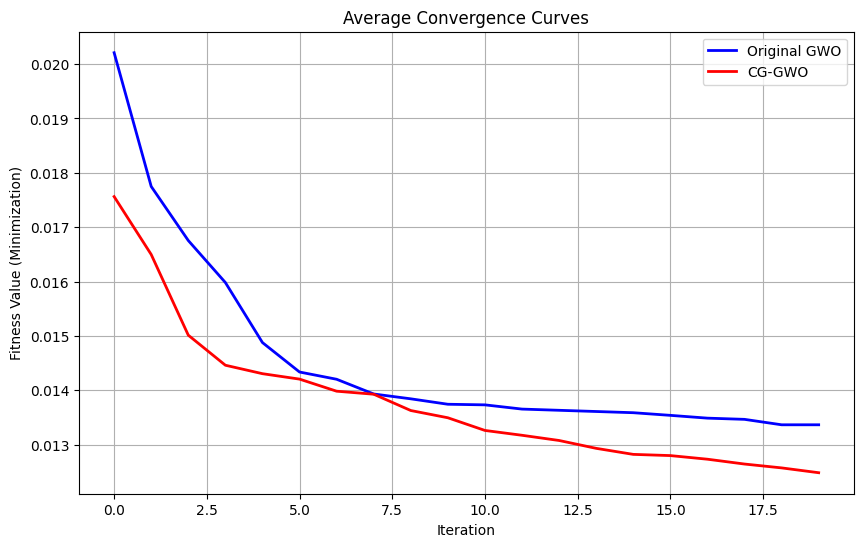

In [33]:
# menampilkan solusi terbaik dan fitness terbaik dari GWO dan CG-GWO
plt.figure(figsize=(10, 6))
avg_history_gwo = np.mean([r['history'] for r in results_gwo], axis=0)
avg_history_cggwo = np.mean([r['history'] for r in results_cggwo], axis=0)
plt.plot(avg_history_gwo, label="Original GWO", color="blue", linewidth=2)
plt.plot(avg_history_cggwo, label="CG-GWO", color="red", linewidth=2)
plt.title("Average Convergence Curves")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value (Minimization)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# fungsi untuk mengevaluasi model terbaik dari solusi yang ditemukan
def evaluate_best_model(solution, model_name):
    binary_features, C, gamma, kernel, class_weight = problem_instance.decode_solution(solution)
    selected_indices = np.where(binary_features == 1)[0]
    svm = SVC(
        C=C,
        gamma=gamma if kernel == "rbf" else "scale",
        kernel=kernel,
        class_weight=class_weight,
        probability=True,
        random_state=42
    )
    
    svm.fit(X_train_scaled[:, selected_indices], y_train)
    y_pred = svm.predict(X_test_scaled[:, selected_indices])
    y_prob = svm.predict_proba(X_test_scaled[:, selected_indices])[:, 1]
    
    return {
        "model": model_name,
        "n_features": len(selected_indices),
        "selected_features": selected_indices,
        "C": C,
        "gamma": gamma,
        "kernel": kernel,
        "class_weight": class_weight,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [47]:
# mengevaluasi model terbaik dari GWO dan CG-GWO
gwo_solutions = evaluate_best_model(best_run_gwo['solution'], "Original GWO")
cggwo_solutions = evaluate_best_model(best_run_cggwo['solution'], "CG-GWO")

# menyusun hasil solusi terbaik ke dalam DataFrame untuk perbandingan
df_solutions = pd.DataFrame({
    "Model": [gwo_solutions["model"], cggwo_solutions["model"]],
    "C": [gwo_solutions["C"], cggwo_solutions["C"]],
    "Gamma": [gwo_solutions["gamma"], cggwo_solutions["gamma"]],
    "Kernel": [gwo_solutions["kernel"], cggwo_solutions["kernel"]],
    "Class Weight": [gwo_solutions["class_weight"], cggwo_solutions["class_weight"]],
    "N Selected Features": [gwo_solutions["n_features"], cggwo_solutions["n_features"]],
    "Selected Features": [
        ", ".join([X.columns[i] for i in gwo_solutions["selected_features"]]),
        ", ".join([X.columns[i] for i in cggwo_solutions["selected_features"]])
    ]
})

df_solutions.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

,Model,C,Gamma,Kernel,Class Weight,N Selected Features,Selected Features
0,Original GWO,1443.976329,0.000103,linear,None,14,"radius1, area1, smoothness1, symmetry1, radius2, smoothness2, compactness2, fractal_dimension2, radius3, perimeter3, area3, compactness3, concavity3, symmetry3"
1,CG-GWO,0.042887,2.149487,linear,balanced,15,"texture1, smoothness1, compactness1, concavity1, concave_points1, fractal_dimension1, radius2, area2, compactness2, fractal_dimension2, radius3, perimeter3, smoothness3, concavity3, concave_points3"


In [36]:
# fungsi untuk menghitung metrik klasifikasi dari solusi yang ditemukan
def classification_metrics(result, y_true):
    y_pred = result["y_pred"]
    return {
        "Model": result["model"],
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

metrics_gwo = classification_metrics(gwo_solutions, y_test)
metrics_cggwo = classification_metrics(cggwo_solutions, y_test)
df_metrics = pd.DataFrame([metrics_gwo, metrics_cggwo])
df_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,Original GWO,0.970760,0.967742,0.952381,0.960000
1,CG-GWO,0.988304,0.984127,0.984127,0.984127


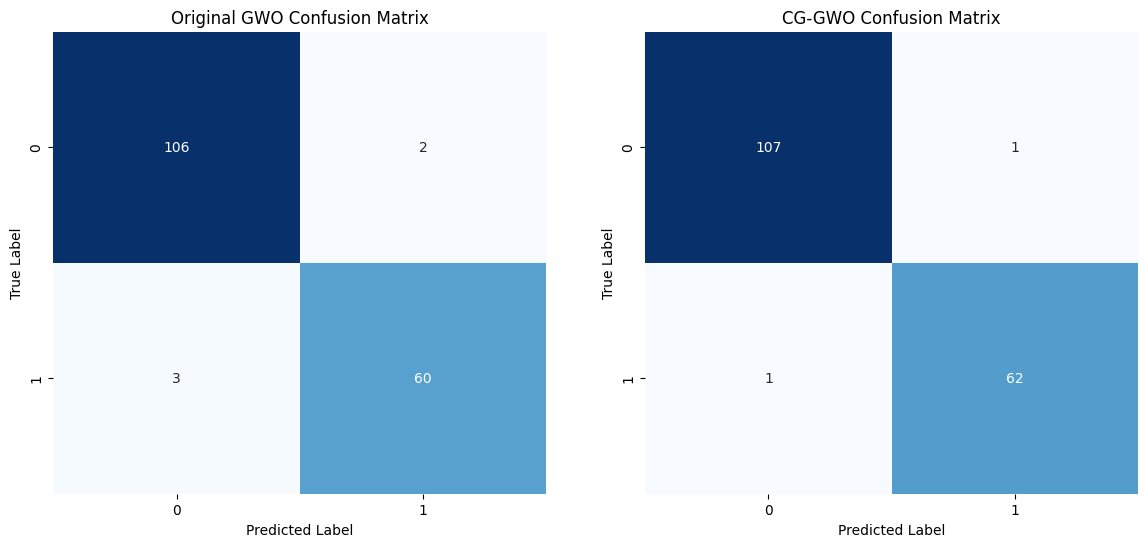

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax = ax.flatten()

for i, result in enumerate([gwo_solutions, cggwo_solutions]):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[i])
    ax[i].set_title(f'{result["model"]} Confusion Matrix')
    ax[i].set_xlabel('Predicted Label')
    ax[i].set_ylabel('True Label')

plt.show()

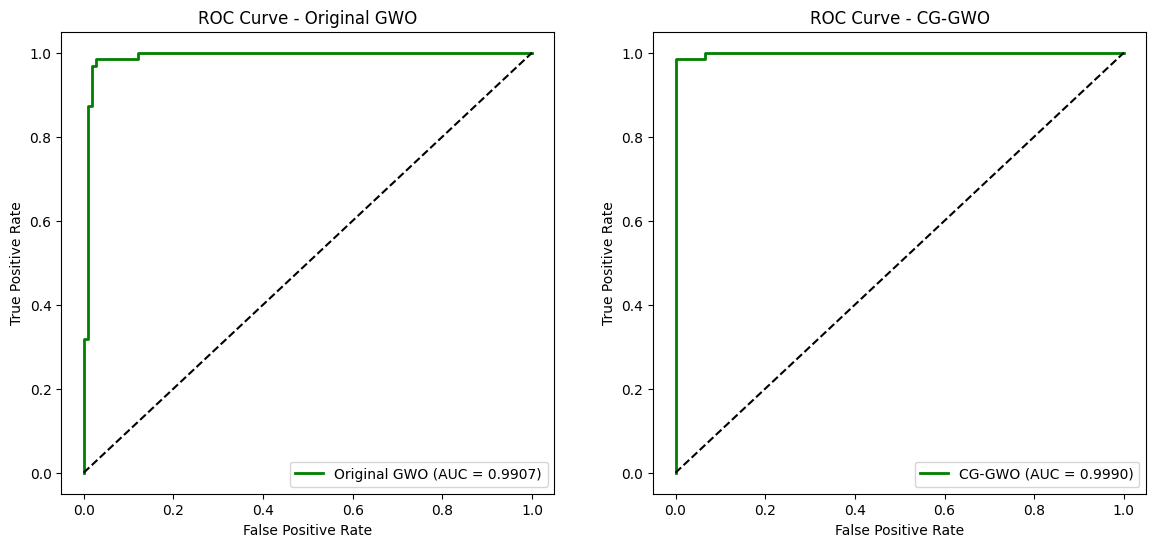

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax = ax.flatten()

for i, result in enumerate([gwo_solutions, cggwo_solutions]):
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    roc_auc = roc_auc_score(y_test, result["y_prob"])
    ax[i].plot(fpr, tpr, label=f'{result["model"]} (AUC = {roc_auc:.4f})', color='green', linewidth=2)
    ax[i].plot([0, 1], [0, 1], 'k--')
    ax[i].set_title(f'ROC Curve - {result["model"]}')
    ax[i].set_xlabel('False Positive Rate')
    ax[i].set_ylabel('True Positive Rate')
    ax[i].legend()

plt.show()

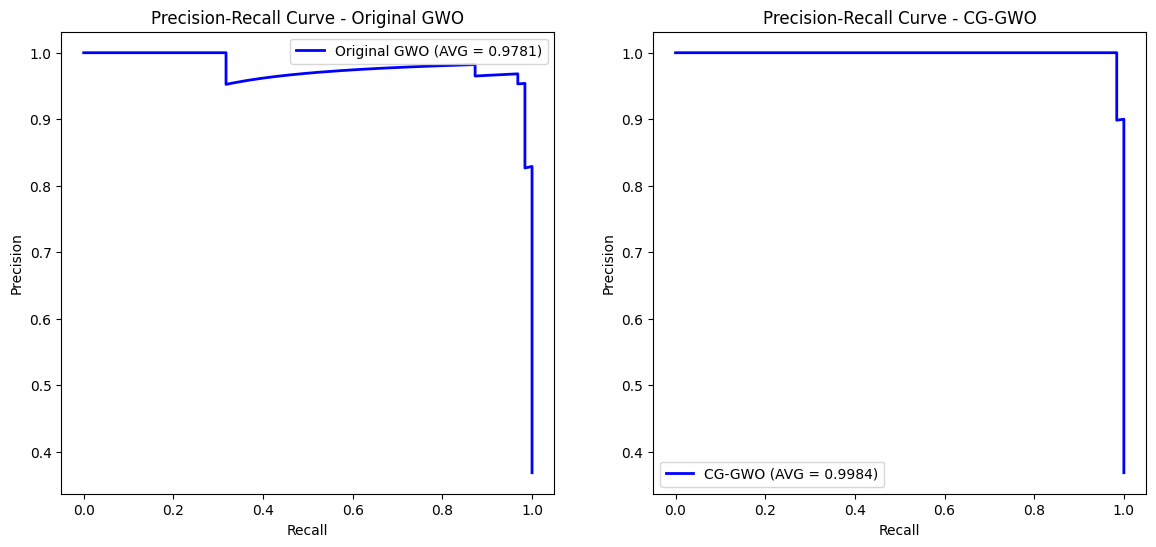

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax = ax.flatten()

for i, result in enumerate([gwo_solutions, cggwo_solutions]):
    prec_optim_curve, rec_optim_curve, _ = precision_recall_curve(y_test, result["y_prob"])
    pr_auc_optim = average_precision_score(y_test, result["y_prob"])
    ax[i].plot(rec_optim_curve, prec_optim_curve, label=f'{result["model"]} (AVG = {pr_auc_optim:.4f})', color='blue', linewidth=2)
    ax[i].set_title(f'Precision-Recall Curve - {result["model"]}')
    ax[i].set_xlabel('Recall')
    ax[i].set_ylabel('Precision')
    ax[i].legend()

plt.show()

## **📊 Statistical Testing**

Untuk mengevaluasi apakah **CG-GWO** memberikan peningkatan yang signifikan dibandingkan **GWO**, digunakan beberapa uji statistik berikut:

- **Paired t-test**  
  Digunakan untuk membandingkan rata-rata performa kedua metode dengan asumsi distribusi normal. Cocok untuk mendeteksi perbedaan signifikan secara parametrik.
- **Wilcoxon Signed-Rank Test**  
  Alternatif non-parametrik dari t-test yang tidak mengasumsikan normalitas data. Lebih robust untuk distribusi yang tidak normal atau terdapat outlier.
- **Permutation Test**  
  Metode berbasis *resampling* yang menguji signifikansi dengan membandingkan hasil observasi terhadap distribusi acak. Sangat fleksibel dan tidak bergantung pada asumsi distribusi tertentu.

Ketiga uji ini digunakan secara komplementer untuk memastikan bahwa peningkatan performa CG-GWO bersifat **konsisten dan signifikan secara statistik**, bukan akibat variasi acak dari proses optimasi yang bersifat *stochastic*.

In [40]:
# menghitung F1-score untuk semua run GWO dan CG-GWO
f1_list_gwo = []
f1_list_cggwo = []

for res_gwo, res_cggwo in zip(results_gwo, results_cggwo):
    
    report_gwo = evaluate_best_model(res_gwo['solution'], "GWO Run")
    report_cggwo = evaluate_best_model(res_cggwo['solution'], "CG-GWO Run")
    
    y_pred_gwo = report_gwo["y_pred"]
    y_pred_cggwo = report_cggwo["y_pred"]
    
    f1_gwo = f1_score(y_test, y_pred_gwo, zero_division=0)
    f1_cggwo = f1_score(y_test, y_pred_cggwo, zero_division=0)
    
    f1_list_gwo.append(f1_gwo)
    f1_list_cggwo.append(f1_cggwo)

f1_list_gwo = np.array(f1_list_gwo)
f1_list_cggwo = np.array(f1_list_cggwo)

In [41]:
# menghitung nilai cohen's d untuk mengukur effect size antara F1-score GWO dan CG-GWO
diff = f1_list_cggwo - f1_list_gwo
effect_size = np.mean(diff) / np.std(diff)

print("\nEffect Size (Cohen's d):", effect_size)


Effect Size (Cohen's d): 0.0658995763712062


In [42]:
# melakukan uji statistik Wilcoxon signed-rank test untuk membandingkan F1-score GWO dan CG-GWO
wilcoxon_stat, p_wilcoxon_value = wilcoxon(f1_list_gwo, f1_list_cggwo)

In [43]:
# melakukan uji statistik paired t-test untuk membandingkan F1-score GWO dan CG-GWO
ttest_stat, p_ttest_value = ttest_rel(f1_list_gwo, f1_list_cggwo)

In [44]:
# melakukan uji statistik permutation test untuk membandingkan F1-score GWO dan CG-GWO
def statistic(x, y):
    return np.mean(x - y)

perm_result = permutation_test(
    (f1_list_gwo, f1_list_cggwo),
    statistic,
    vectorized=False,
    n_resamples=10000,
    alternative='greater'
)

perm_test = perm_result.statistic
p_prem_value = perm_result.pvalue

In [45]:
# menyusun hasil perbandingan uji statistik ke dalam DataFrame
alpha = 0.05

def interpret(p):
    return "Signifikan" if p < alpha else "Tidak Signifikan"

comparison_stats = pd.DataFrame([
    {
        "Nama Test": "Wilcoxon Signed-Rank",
        "Test Statistic": wilcoxon_stat,
        "p-value": p_wilcoxon_value,
        "Kesimpulan": interpret(p_wilcoxon_value)
    },
    {
        "Nama Test": "Paired t-test",
        "Test Statistic": ttest_stat,
        "p-value": p_ttest_value,
        "Kesimpulan": interpret(p_ttest_value)
    },
    {
        "Nama Test": "Permutation Test",
        "Test Statistic": perm_test,
        "p-value": p_prem_value,
        "Kesimpulan": interpret(p_prem_value)
    }
])

In [46]:
# membulatkan nilai statistik dan p-value untuk tampilan yang lebih rapi
comparison_stats = comparison_stats.round(6)
comparison_stats

,Nama Test,Test Statistic,p-value,Kesimpulan
0,Wilcoxon Signed-Rank,166.000000,0.580418,Tidak Signifikan
1,Paired t-test,-0.354880,0.725247,Tidak Signifikan
2,Permutation Test,-0.001309,0.642736,Tidak Signifikan
